# EMA 6938 — Data Science for Materials
## Week 1 Lab Notebook: Introduction to Materials Data Science

**Name:** *ANOSIKE KELECHI KENNETH*  
**Date:** *5/14/2026*  
**Kernel:** Python (matds) 
PERPLEXITY AI-ASSISTED SOLUTIONS USED

---

### About this notebook

This notebook has five parts:

| Part | Title | When | Points |
|------|-------|------|--------|
| A | Environment verification | In-class, Day 1 | Completion |
| B | Python primer | In-class, Day 1 | Completion |
| C | NumPy & pandas with materials data | In-class, Day 1 | Completion |
| D | Materials Project API | In-class, Day 1 | Completion |
| E | Take-home reflection | Independent, due Sunday 11:59 PM | Graded |

**Parts A–D** are completed during the Day 1 lab session (75 min). Follow along with the instructor's screenshare.  
**Part E** is take-home — complete it independently before Sunday 11:59 PM.

**Submission:** Upload this `.ipynb` file to Canvas. Run `Kernel → Restart & Run All` before submitting to confirm all cells execute cleanly.

> **AI tool disclosure:** If you used any AI coding assistant (GitHub Copilot, ChatGPT, etc.) while completing this notebook, describe briefly which tool, for what purpose, and what you verified yourself. Delete this line if no AI tools were used.

---

## Part A — Environment Verification
*(In-class — do not modify these cells)*

Run each cell in order. If any cell raises an `ImportError`, post the error message in the **General Course Questions** discussion thread on Canvas immediately — do not wait until the deadline.

In [1]:
# Cell A1 — Verify Python version
import sys
print(f"Python version: {sys.version}")
assert sys.version_info >= (3, 10), "Python 3.10+ required. Please reinstall the matds environment."
print("✅ Python version OK")

Python version: 3.10.20 | packaged by conda-forge | (main, Mar  5 2026, 16:36:49) [MSC v.1944 64 bit (AMD64)]
✅ Python version OK


In [2]:
# Cell A2 — Verify all core library imports
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import pymatgen.core
from pymatgen.core import Lattice, Structure

packages = {
    "NumPy":     np.__version__,
    "pandas":    pd.__version__,
    "matplotlib": matplotlib.__version__,
    "pymatgen":  pymatgen.core.__version__,
}

print("Package versions:")
for pkg, ver in packages.items():
    print(f"  {pkg:<15} {ver}")

print("\n✅ All core imports successful")

Package versions:
  NumPy           1.26.4
  pandas          2.3.3
  matplotlib      3.10.9
  pymatgen        2024.2.8

✅ All core imports successful


In [3]:
# Cell A3 — Verify Materials Project API key
from dotenv import load_dotenv
import os

load_dotenv()  # Reads .env file from repository root
API_KEY = os.getenv("MP_API_KEY")

if API_KEY:
    print(f"✅ MP API key loaded ({len(API_KEY)} characters)")
    print("   Key preview:", API_KEY[:4] + "*" * (len(API_KEY) - 8) + API_KEY[-4:])
else:
    print("❌ MP API key not found.")
    print("   Create a .env file in the repository root with:")
    print("   MP_API_KEY=your_actual_key_here")
    print("   Register for a free key at: https://next.materialsproject.org/api")

✅ MP API key loaded (32 characters)
   Key preview: wvwM************************aZRE


In [4]:
# Cell A4 — Test Materials Project API connection
# Note: API key must be active (can take up to 1 hour after registration)
# If this cell fails, use the Binder fallback link posted in the Canvas Week 1 module

from mp_api.client import MPRester

try:
    with MPRester(API_KEY) as mpr:
        # Minimal test query — fetches one entry
        result = mpr.materials.summary.search(material_ids=["mp-5020"], fields=["formula_pretty"])
        print(f"✅ MP API connection successful")
        print(f"   Test query returned: {result[0].formula_pretty}")
except Exception as e:
    print(f"❌ MP API connection failed: {e}")
    print("   If your key is new, wait up to 1 hour and retry.")
    print("   Use the Binder fallback link in Canvas in the meantime.")

Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

✅ MP API connection successful
   Test query returned: BaTiO3


---
## Part B — Python Primer
*(In-class — complete each cell, then answer the Tasks in markdown)*

All examples use materials science context. Every data structure here reappears in later weeks.

In [5]:
# Cell B1 — Dictionaries: element properties

elements = {
    'Fe': {'atomic_mass': 55.845, 'melting_point_K': 1811, 'crystal_structure': 'BCC'},
    'Al': {'atomic_mass': 26.982, 'melting_point_K': 933,  'crystal_structure': 'FCC'},
    'Ti': {'atomic_mass': 47.867, 'melting_point_K': 1941, 'crystal_structure': 'HCP'},
    }

# Example: access Fe melting point
print(f"Fe melting point: {elements['Fe']['melting_point_K']} K")

# Example: iterate over all elements
print("\nAll elements:")
for symbol, props in elements.items():
    print(f"  {symbol}: {props['crystal_structure']}, mp = {props['melting_point_K']} K")

Fe melting point: 1811 K

All elements:
  Fe: BCC, mp = 1811 K
  Al: FCC, mp = 933 K
  Ti: HCP, mp = 1941 K


In [6]:
# Cell B1 — TASK
# Add Cu (atomic_mass=63.546, melting_point_K=1358, crystal_structure='FCC')
# and Ni (atomic_mass=58.693, melting_point_K=1728, crystal_structure='FCC')
# to the elements dictionary, then print the updated dictionary.

# Your code here:
elements = {
    'Fe': {'atomic_mass': 55.845, 'melting_point_K': 1811, 'crystal_structure': 'BCC'},
    'Al': {'atomic_mass': 26.982, 'melting_point_K': 933,  'crystal_structure': 'FCC'},
    'Ti': {'atomic_mass': 47.867, 'melting_point_K': 1941, 'crystal_structure': 'HCP'},
    'Cu': {'atomic_mass': 63.546, 'melting_point_K': 1358, 'crystal_structure': 'FCC'},
    'Ni': {'atomic_mass': 58.698, 'melting_point_K': 1728, 'crystal_structure': 'FCC'},
}

print("\nAll elements:")
for symbol, props in elements.items():
    print(f"  {symbol}: {props['crystal_structure']}, mp = {props['melting_point_K']} K")


All elements:
  Fe: BCC, mp = 1811 K
  Al: FCC, mp = 933 K
  Ti: HCP, mp = 1941 K
  Cu: FCC, mp = 1358 K
  Ni: FCC, mp = 1728 K


In [7]:
# Cell B2 — Loops and list comprehensions: materials property lists

# Standard loop
melting_points = []
for symbol, props in elements.items():
    melting_points.append(props['melting_point_K'])
print("Melting points (loop):", melting_points)

# Equivalent list comprehension — more Pythonic
melting_points_lc = [props['melting_point_K'] for props in elements.values()]
print("Melting points (list comp):", melting_points_lc)

Melting points (loop): [1811, 933, 1941, 1358, 1728]
Melting points (list comp): [1811, 933, 1941, 1358, 1728]


In [8]:
# Cell B2 — TASK
# Using a list comprehension, create a list of (symbol, melting_point_K) tuples
# for elements with melting point above 1500 K.
# Expected output (order may vary): [('Fe', 1811), ('Ti', 1941), ('Ni', 1728)]

# Your code here:
refractory = [(symbol, props['melting_point_K'])
for symbol, props in elements.items()
if props ['melting_point_K'] > 1500]
print("Element with mp > 1500 K:", refractory)

Element with mp > 1500 K: [('Fe', 1811), ('Ti', 1941), ('Ni', 1728)]


In [9]:
# Cell B3 — Functions: unit conversions for materials data

def celsius_to_kelvin(T_C: float) -> float:
    """Convert temperature from Celsius to Kelvin."""
    return T_C + 273.15

def kelvin_to_celsius(T_K: float) -> float:
    """Convert temperature from Kelvin to Celsius."""
    return T_K - 273.15

# Test
print(f"Room temperature: {celsius_to_kelvin(25):.2f} K")
print(f"Fe melting point: {kelvin_to_celsius(1811):.2f} °C")

Room temperature: 298.15 K
Fe melting point: 1537.85 °C


In [10]:
# Cell B3 — TASK
# Write a function eV_to_kJ_per_mol(energy_eV) that converts formation energy
# from eV/atom to kJ/mol.
# Conversion: 1 eV = 96.485 kJ/mol
#
# Then use it to convert the following typical DFT formation energies:
# Fe2O3: -1.67 eV/atom
# Al2O3: -3.43 eV/atom
# TiO2:  -3.11 eV/atom

# Your code here:
def eV_to_kJ_per_mol(energy_eV):
    return energy_eV * 96.485 #replace with your implementation
    
for material, energy in [('Fe2O3', -1.67), ('Al2O3', -3.43), ('TiO2', -3.11)]:
    print(f"{material}: {eV_to_kJ_per_mol(energy):.1f} kJ/mol")

Fe2O3: -161.1 kJ/mol
Al2O3: -330.9 kJ/mol
TiO2: -300.1 kJ/mol


---
## Part C — NumPy & Pandas with Materials Data
*(In-class — run each cell, complete tasks)*

We use a small sample dataset of Materials Project entries. The CSV contains bandgap and formation energy values for 50 binary oxides.

In [11]:
# Cell C1 — Load and inspect the sample dataset
import pandas as pd
import numpy as np

df = pd.read_csv('week1_materials_sample.csv')

print(f"Shape: {df.shape}  ({df.shape[0]} materials, {df.shape[1]} columns)")
print(f"\nColumn names: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
df.head()

Shape: (80, 10)  (80 materials, 10 columns)

Column names: ['material_id', 'formula', 'elements', 'band_gap', 'formation_energy_per_atom', 'energy_above_hull', 'is_stable', 'volume_per_atom', 'density', 'nsites']

First 5 rows:


,material_id,formula,elements,band_gap,formation_energy_per_atom,energy_above_hull,is_stable,volume_per_atom,density,nsites
0,mp-1273559,VO2,O-V,0.8258,-2.4209,0.1016,False,11.8880,3.8618,18
1,mp-1182115,BrO3,Br-O,0.0000,0.2275,0.3517,False,15.3629,3.4562,8
2,mp-755060,Cs2O,Cs-O,0.2682,-1.1219,0.0583,False,32.8452,4.7491,6
3,mp-32662,WO3,O-W,1.4934,-2.1811,0.0098,False,15.7582,6.1076,24
4,mp-778470,Mn2O3,Mn-O,0.0000,-1.9351,0.0789,False,11.8012,4.4429,160


In [12]:
# Cell C2 — Statistical summary
print("Statistical summary:")
df.describe().round(3)

Statistical summary:


,band_gap,formation_energy_per_atom,energy_above_hull,volume_per_atom,density,nsites
count,80.000,80.000,80.000,80.000,80.000,80.000
mean,1.842,-1.983,0.232,15.547,4.192,38.588
std,2.065,1.116,0.355,5.939,2.348,57.358
min,0.000,-4.090,0.000,6.080,1.042,2.000
25%,0.004,-3.177,0.021,11.831,2.356,10.000
50%,1.017,-1.816,0.088,14.456,3.867,18.500
75%,2.798,-1.265,0.290,17.960,5.663,40.500
max,6.442,0.770,2.120,49.118,11.979,360.000


In [13]:
# Cell C2 — TASK
# 1. How many unique elements appear across all compositions in the dataset?
#    Hint: look at the 'elements' column — it stores element lists as strings.
# 2. How many materials have a bandgap of exactly 0 eV (i.e., are metallic)?
# 3. What is the mean formation energy of materials with bandgap > 3 eV?

#NOTE: PERPLEXITY AI-ASSISTED
# Your code here:

# 1. Unique elements
all_elements = set(e for elem_list in df['elements'] for e in elem_list)
num_unique_elements = len(all_elements)
print("1. Unique elements:", num_unique_elements)


# 2. Metallic materials (bandgap == 0)
num_metallic = (df['band_gap'] == 0).sum()
print("2. Metallic materials (bandgap == 0):", num_metallic)


# 3. Mean formation energy of wide-bandgap materials
mean_E_form_widegap = df.loc[df['band_gap'] > 3, 'formation_energy_per_atom'].mean()
print("3. Mean formation energy of wide-bandgap materials:", mean_E_form_widegap)


1. Unique elements: 34
2. Metallic materials (bandgap == 0): 20
3. Mean formation energy of wide-bandgap materials: -2.9513749999999996


In [14]:
# Cell C3 — NumPy operations on property arrays

bandgaps = df['band_gap'].values  # Extract as NumPy array
form_energies = df['formation_energy_per_atom'].values

print(f"Bandgap array type: {type(bandgaps)}")
print(f"Min bandgap:  {np.min(bandgaps):.3f} eV")
print(f"Max bandgap:  {np.max(bandgaps):.3f} eV")
print(f"Mean bandgap: {np.mean(bandgaps):.3f} eV")
print(f"Std bandgap:  {np.std(bandgaps):.3f} eV")
print(f"\nPearson correlation (bandgap vs. formation energy): {np.corrcoef(bandgaps, form_energies)[0,1]:.3f}")

Bandgap array type: <class 'numpy.ndarray'>
Min bandgap:  0.000 eV
Max bandgap:  6.442 eV
Mean bandgap: 1.842 eV
Std bandgap:  2.052 eV

Pearson correlation (bandgap vs. formation energy): -0.494


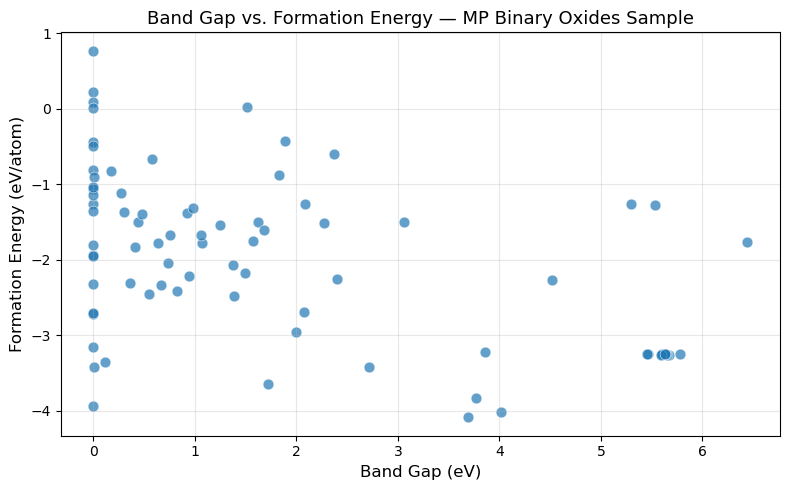

Plot saved as week1_scatter.png


In [15]:
# Cell C4 — Scatter plot: bandgap vs. formation energy
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

scatter = ax.scatter(
    df['band_gap'],
    df['formation_energy_per_atom'],
    alpha=0.7,
    edgecolors='white',
    linewidth=0.5,
    s=60
)

ax.set_xlabel('Band Gap (eV)', fontsize=12)
ax.set_ylabel('Formation Energy (eV/atom)', fontsize=12)
ax.set_title('Band Gap vs. Formation Energy — MP Binary Oxides Sample', fontsize=13)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('week1_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as week1_scatter.png")

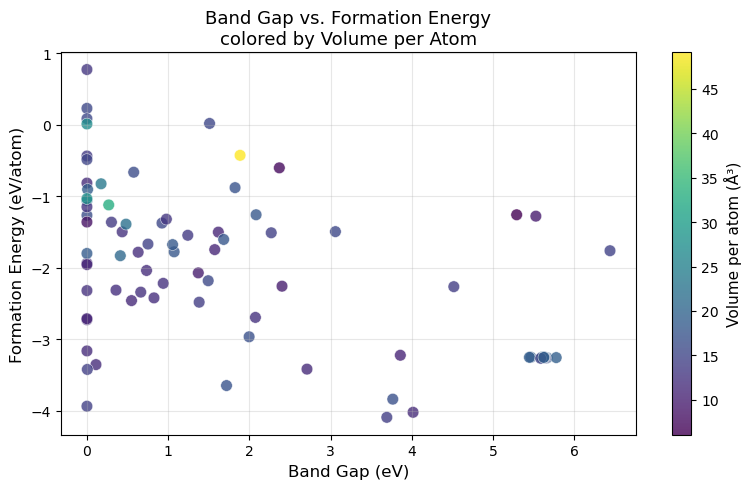

Observation: larger-volume oxides (yellow) tend to cluster at lower bandgaps,
suggesting a loose inverse relationship between unit cell volume and bandgap.


In [16]:
# Cell C4 — TASK
# The scatter plot above uses a single color for all points.
# Modify it to add a third dimension: color each point by its
# 'volume_per_atom' value using a colormap (e.g. 'viridis').
# Add a colorbar with the label 'Volume per atom (Å³)'.
#
# Hint: in scatter(), use c=df['volume_per_atom'] and cmap='viridis',
# then use plt.colorbar() on the scatter object.

# Your code here:
fig, ax = plt.subplots(figsize=(8, 5))

scatter = ax.scatter(
    df['band_gap'],
    df['formation_energy_per_atom'],
    c=df['volume_per_atom'],      # color by volume per atom
    cmap='viridis',
    alpha=0.8,
    edgecolors='white',
    linewidth=0.4,
    s=70
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Volume per atom (Å³)', fontsize=11)

ax.set_xlabel('Band Gap (eV)', fontsize=12)
ax.set_ylabel('Formation Energy (eV/atom)', fontsize=12)
ax.set_title('Band Gap vs. Formation Energy\ncolored by Volume per Atom', fontsize=13)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('week1_scatter_colored.png', dpi=150, bbox_inches='tight')
plt.show()

print("Observation: larger-volume oxides (yellow) tend to cluster at lower bandgaps,")
print("suggesting a loose inverse relationship between unit cell volume and bandgap.")

---
## Part D — Materials Project API
*(In-class — follow along with the instructor)*

You already tested the API connection in Part A. Now you will use it to retrieve real crystal structures and explore what information is available.

In [17]:
# Cell D1 — Your first real API call: BaTiO3
from mp_api.client import MPRester
from dotenv import load_dotenv
import os

load_dotenv()
API_KEY = os.getenv("MP_API_KEY")

with MPRester(API_KEY) as mpr:
    struct = mpr.get_structure_by_material_id("mp-5020")  # BaTiO3 — tetragonal

print("Structure retrieved!")
print(struct)

Retrieving MaterialsDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Structure retrieved!
Full Formula (Ba1 Ti1 O3)
Reduced Formula: BaTiO3
abc   :   4.033807   4.033806   4.033806
angles:  89.836383  89.836370  89.836387
pbc   :       True       True       True
Sites (5)
  #  SP           a         b         c    magmom
---  ----  --------  --------  --------  --------
  0  Ba    0.999854  0.999854  0.999854         0
  1  Ti    0.486662  0.486662  0.486662         0
  2  O     0.020283  0.51105   0.51105         -0
  3  O     0.51105   0.51105   0.020283        -0
  4  O     0.51105   0.020283  0.51105         -0


In [18]:
# Cell D2 — Inspect the Structure object

print(f"Formula:       {struct.formula}")
print(f"Reduced:       {struct.reduced_formula}")
print(f"Space group:   {struct.get_space_group_info()}")
print(f"Num sites:     {len(struct)}")
print(f"Lattice (Å):   a={struct.lattice.a:.4f}, b={struct.lattice.b:.4f}, c={struct.lattice.c:.4f}")
print(f"Volume (Å³):   {struct.volume:.4f}")
print()
print("Atomic sites (fractional coordinates):")
for site in struct:
    print(f"  {site.species_string:<4}  {site.frac_coords}")

Formula:       Ba1 Ti1 O3
Reduced:       BaTiO3
Space group:   ('R3m', 160)
Num sites:     5
Lattice (Å):   a=4.0338, b=4.0338, c=4.0338
Volume (Å³):   65.6356

Atomic sites (fractional coordinates):
  Ba    [0.99985396 0.99985396 0.99985396]
  Ti    [0.48666229 0.48666229 0.48666229]
  O     [0.02028337 0.51104969 0.51104969]
  O     [0.51104969 0.51104969 0.02028337]
  O     [0.51104969 0.02028337 0.51104969]


C:\Users\anosike.kelechik\AppData\Local\anaconda3\envs\matds\lib\site-packages\pymatgen\symmetry\analyzer.py:129: DeprecationWarning: dict interface is deprecated. Use attribute interface instead
  return self._space_group_data["international"]


In [19]:
# Cell D3 — Retrieve computed properties alongside the structure

with MPRester(API_KEY) as mpr:
    results = mpr.materials.summary.search(
        material_ids=["mp-5020"],
        fields=["formula_pretty", "band_gap", "formation_energy_per_atom",
                "energy_above_hull", "is_stable", "volume", "density"]
    )

entry = results[0]
print(f"Material:                 {entry.formula_pretty}")
print(f"Band gap:                 {entry.band_gap:.3f} eV")
print(f"Formation energy:         {entry.formation_energy_per_atom:.4f} eV/atom")
print(f"Energy above hull:        {entry.energy_above_hull:.4f} eV/atom")
print(f"Thermodynamically stable: {entry.is_stable}")
print(f"Volume:                   {entry.volume:.3f} Å³")
print(f"Density:                  {entry.density:.3f} g/cm³")

Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Material:                 BaTiO3
Band gap:                 2.509 eV
Formation energy:         -3.4922 eV/atom
Energy above hull:        0.0000 eV/atom
Thermodynamically stable: False
Volume:                   65.636 Å³
Density:                  5.900 g/cm³


In [20]:
# Cell D4 — The Lattice: the repeating box
# The lattice defines the shape and size of the repeating unit cell — described by three vectors (a, b, c) and three angles (α, β, γ).
# Cell D4 — Inspect the lattice
lat = struct.lattice
print("Lattice object:")
print(lat)
print()
print(f"a = {lat.a:.4f} Å")
print(f"b = {lat.b:.4f} Å")
print(f"c = {lat.c:.4f} Å")
print(f"α = {lat.alpha:.2f}°")
print(f"β = {lat.beta:.2f}°")
print(f"γ = {lat.gamma:.2f}°")
print(f"Volume = {lat.volume:.4f} Å³")

Lattice object:
4.033793 0.001180 0.010336
0.010312 4.033779 0.010336
0.001184 0.001180 4.033806

a = 4.0338 Å
b = 4.0338 Å
c = 4.0338 Å
α = 89.84°
β = 89.84°
γ = 89.84°
Volume = 65.6356 Å³


In [21]:
# Cell D5 — Atomic Sites: who is where
# Each site in the structure contains:
# The element (or species) at that position
# Fractional coordinates — position expressed as fractions of the lattice vectors (always between 0 and 1)
# Cartesian coordinates — the real-space position in Ångströms
# Cell D5 — Inspect atomic sites
print(f"Structure has {len(struct)} sites:\n")
print(f"{'Index':<6} {'Element':<10} {'Frac. coords':<35} {'Cart. coords (Å)'}")
print("-" * 75)

for i, site in enumerate(struct):
    fc = site.frac_coords
    cc = site.coords
    print(f"{i:<6} {site.species_string:<10} "
          f"({fc[0]:.4f}, {fc[1]:.4f}, {fc[2]:.4f})   "
          f"({cc[0]:.3f}, {cc[1]:.3f}, {cc[2]:.3f})")

Structure has 5 sites:

Index  Element    Frac. coords                        Cart. coords (Å)
---------------------------------------------------------------------------
0      Ba         (0.9999, 0.9999, 0.9999)   (4.045, 4.036, 4.054)
1      Ti         (0.4867, 0.4867, 0.4867)   (1.969, 1.964, 1.973)
2      O          (0.0203, 0.5110, 0.5110)   (0.088, 2.062, 2.067)
3      O          (0.5110, 0.5110, 0.0203)   (2.067, 2.062, 0.092)
4      O          (0.5110, 0.0203, 0.5110)   (2.062, 0.083, 2.067)


In [22]:
# Cell D6 — Explore: change the material ID

# Try fetching a different material.
# Some suggestions to try (remove the # and run):
# mp-7000    — SiO2 (quartz)
# mp-2133    — Fe2O3 (hematite)
# mp-22526   — NaCl (halite/rocksalt)
# mp-2534    — Al2O3 (corundum)

MATERIAL_ID = "mp-7000"  # Change this to explore

with MPRester(API_KEY) as mpr:
    struct2 = mpr.get_structure_by_material_id(MATERIAL_ID)
    results2 = mpr.materials.summary.search(
        material_ids=[MATERIAL_ID],
        fields=["formula_pretty", "band_gap", "formation_energy_per_atom", "is_stable"]
    )

e = results2[0]
print(f"Material ID:     {MATERIAL_ID}")
print(f"Formula:         {e.formula_pretty}")
print(f"Band gap:        {e.band_gap:.3f} eV")
print(f"Formation energy:{e.formation_energy_per_atom:.4f} eV/atom")
print(f"Stable:          {e.is_stable}")
print(f"Space group:     {struct2.get_space_group_info()}")

Retrieving MaterialsDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Material ID:     mp-7000
Formula:         SiO2
Band gap:        5.719 eV
Formation energy:-3.2728 eV/atom
Stable:          True
Space group:     ('P3_121', 152)


C:\Users\anosike.kelechik\AppData\Local\anaconda3\envs\matds\lib\site-packages\pymatgen\symmetry\analyzer.py:129: DeprecationWarning: dict interface is deprecated. Use attribute interface instead
  return self._space_group_data["international"]


In [23]:
# Cell D7 — Nearest neighbors: who is bonded to whom?

# Get nearest neighbors of the first site in BaTiO3
site_index = 0
site = struct[site_index]
neighbors = struct.get_neighbors(site, r=3.5)  # within 3.5 Angstrom

print(f"Central atom: {site.species_string} at {site.frac_coords.round(3)}")
print(f"Neighbors within 3.5 Å:")
for nbr in sorted(neighbors, key=lambda x: x.nn_distance):
    print(f"  {nbr.species_string:<4}  distance = {nbr.nn_distance:.4f} Å")

Central atom: Ba at [1. 1. 1.]
Neighbors within 3.5 Å:
  O     distance = 2.7933 Å
  O     distance = 2.7933 Å
  O     distance = 2.7933 Å
  O     distance = 2.8502 Å
  O     distance = 2.8502 Å
  O     distance = 2.8502 Å
  O     distance = 2.8502 Å
  O     distance = 2.8502 Å
  O     distance = 2.8502 Å
  O     distance = 2.9219 Å
  O     distance = 2.9219 Å
  O     distance = 2.9219 Å
  Ti    distance = 3.4109 Å
  Ti    distance = 3.4602 Å
  Ti    distance = 3.4602 Å
  Ti    distance = 3.4602 Å


In [24]:
# Cell D8 — Reading and Writing CIF Files
# CIF (Crystallographic Information File) is the standard format for crystal structures from X-ray and neutron diffraction.
#Pymatgen can read and write them seamlessly.
# Cell D8 — Export to CIF and read back

# Write to CIF
struct.to(filename="BaTiO3.cif")
print("Written: BaTiO3.cif")

# Read back from CIF
struct_from_cif = Structure.from_file("BaTiO3.cif")
print(f"Read back: {struct_from_cif.formula} — {len(struct_from_cif)} sites")
print()
print("This is what your experimental crystallography data looks like to Python.")
print("Any CIF file from a diffraction experiment can be loaded this way.")

Written: BaTiO3.cif
Read back: Ba1 Ti1 O3 — 5 sites

This is what your experimental crystallography data looks like to Python.
Any CIF file from a diffraction experiment can be loaded this way.


C:\Users\anosike.kelechik\AppData\Local\anaconda3\envs\matds\lib\site-packages\pymatgen\io\cif.py:1606: FutureWarning: We strongly discourage using implicit binary/text `mode`, and this would not be allowed after 2025-06-01. I.e. you should pass t/b in `mode`.
  with zopen(filename, mode=mode) as file:


---
## Part E — Take-Home Reflection
*(Complete independently — due Sunday 11:59 PM)*

These cells require written answers (in markdown) and extended code. Read all three questions before starting — they build on each other.

**Grading:** Part E is the only graded section. It is assessed on correctness of code, quality of scientific reasoning, and clarity of written responses.

### E1 — The Pymatgen Structure object

**Question:** In 2–3 sentences, explain what the Pymatgen `Structure` object represents physically. What information does it contain that a simple chemical formula (e.g. BaTiO₃) does not? Why does this extra information matter for machine learning in materials science?

**Your answer:** *(A Pymatgen Structure object represents the full crystal structure: the lattice vectors defining the periodic unit cell and the precise 3D positions and species of all atoms inside that cell. This goes far beyond a simple formula like BaTiO₃, which only encodes stoichiometry and not how atoms are arranged, their symmetry, or their local environments. That extra structural detail matters for machine learning because many key properties (band gap, stability, ionic conductivity, etc.) depend sensitively on atomic geometry and bonding, so models trained only on composition miss crucial structure–property relationships.)*

### E2 — Improve the scatter plot

**Task:** Return to the scatter plot from Cell C4 (bandgap vs. formation energy). Identify **two scientific improvements** and implement them. In a markdown cell below your improved plot, explain what you changed and why each change makes the plot more scientifically informative.

Possible improvements (choose any two — do not just pick the easiest ones):
- Add error bars if uncertainty data is available
- Add a horizontal line at bandgap = 0 to separate metals from semiconductors/insulators
- Label the 3 materials with the highest bandgap with their formula
- Add a marginal histogram on one axis to show the property distribution
- Color points by crystal system and add a legend
- Use a log scale on the x-axis and justify why

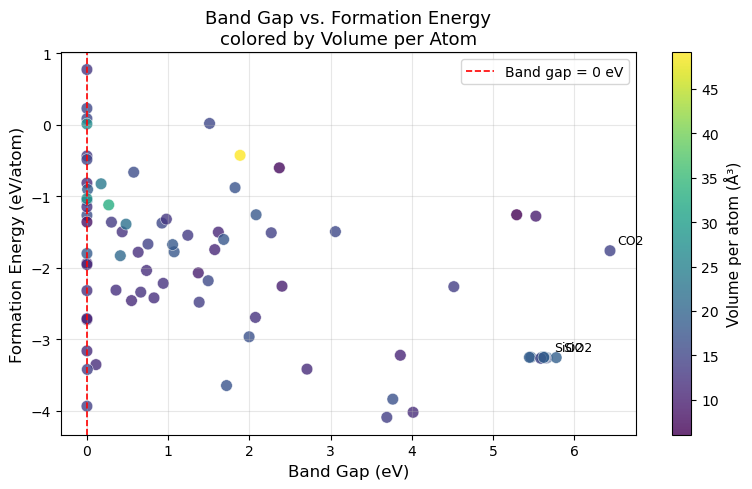

In [25]:
# Cell E2 — Improved scatter plot
# Your code here: 

# PERPLEXITY AI-ASSISTED

fig, ax = plt.subplots(figsize=(8, 5))

# Base scatter: color by volume per atom (as before)
scatter = ax.scatter(
    df['band_gap'],
    df['formation_energy_per_atom'],
    c=df['volume_per_atom'],
    cmap='viridis',
    alpha=0.8,
    edgecolors='white',
    linewidth=0.4,
    s=70
)

# Improvement 1: horizontal line at band_gap = 0 (metals vs semiconductors/insulators)
ax.axvline(x=0.0, color='red', linestyle='--', linewidth=1.2, label='Band gap = 0 eV')

# Improvement 2: label the 3 materials with the highest band gaps
top3 = df.nlargest(3, 'band_gap')   # assumes df has a 'formula' column
for _, row in top3.iterrows():
    ax.annotate(
        row['formula'],
        (row['band_gap'], row['formation_energy_per_atom']),
        textcoords='offset points',
        xytext=(5, 5),
        fontsize=9,
        color='black'
    )

# Colorbar and axes labels
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Volume per atom (Å³)', fontsize=11)

ax.set_xlabel('Band Gap (eV)', fontsize=12)
ax.set_ylabel('Formation Energy (eV/atom)', fontsize=12)
ax.set_title('Band Gap vs. Formation Energy\ncolored by Volume per Atom', fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig('week1_scatter_improved.png', dpi=150, bbox_inches='tight')
plt.show()

**What I changed and why:** *(I added a vertical line at band gap = 0 eV to clearly separate metallic compounds (left of the line) from semiconductors and insulators (right of the line), making it easier to compare trends in formation energy between these classes.I labeled the three compounds with the largest band gaps, which highlights the most insulating materials and helps relate specific chemistries to extreme electronic properties that may be of special interest for applications.)*

### E3 — Retrieve and describe a material of your choice

**Task:** Choose any material relevant to your own research area and retrieve it from the Materials Project. It can be anything — an oxide, an alloy, a semiconductor, a 2D material — as long as it is in the MP database.

Then complete the analysis below.

In [26]:
# Cell E3a — Retrieve your chosen material
# Replace 'mp-XXXX' with the actual Materials Project ID of your material.
# Find the ID by searching at https://materialsproject.org

MY_MATERIAL_ID = 'mp-1216686'  # ← Replace this

with MPRester(API_KEY) as mpr:
    my_struct = mpr.get_structure_by_material_id(MY_MATERIAL_ID)
    my_results = mpr.materials.summary.search(
        material_ids=[MY_MATERIAL_ID],
        fields=["formula_pretty", "band_gap", "formation_energy_per_atom",
                "energy_above_hull", "is_stable", "density",
                "volume", "nsites", "symmetry"]
    )

my_entry = my_results[0]

print("=" * 50)
print(f"Material ID:          {MY_MATERIAL_ID}")
print(f"Formula:              {my_entry.formula_pretty}")
print(f"Space group:          {my_struct.get_space_group_info()}")
print(f"Number of sites:      {my_entry.nsites}")
print(f"Volume:               {my_entry.volume:.3f} Å³")
print(f"Density:              {my_entry.density:.3f} g/cm³")
print(f"Band gap:             {my_entry.band_gap:.3f} eV")
print(f"Formation energy:     {my_entry.formation_energy_per_atom:.4f} eV/atom")
print(f"Energy above hull:    {my_entry.energy_above_hull:.4f} eV/atom")
print(f"Thermodynamic stable: {my_entry.is_stable}")
print("=" * 50)

Retrieving MaterialsDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Material ID:          mp-1216686
Formula:              TiNbO4
Space group:          ('Cmmm', 65)
Number of sites:      6
Volume:               68.945 Å³
Density:              4.932 g/cm³
Band gap:             0.000 eV
Formation energy:     -3.1748 eV/atom
Energy above hull:    0.0398 eV/atom
Thermodynamic stable: False


C:\Users\anosike.kelechik\AppData\Local\anaconda3\envs\matds\lib\site-packages\pymatgen\symmetry\analyzer.py:129: DeprecationWarning: dict interface is deprecated. Use attribute interface instead
  return self._space_group_data["international"]


In [27]:
# Cell E3b — Nearest neighbor analysis for your material
# For each unique species in your structure, find its nearest neighbor
# and report the bond distance.

# Your code here:
# PERPLEXITY AI-ASSISTED

from mp_api.client import MPRester

API_KEY = "qj8ToHbz2L1kqeSTHLICxIQjpzB9TKfS"

# Step 1: search for Ti–Nb–O materials and pick one
with MPRester(API_KEY) as mpr:
    docs = mpr.materials.summary.search(
        elements=["Ti", "Nb", "O"],
        # require exactly Ti–Nb–O; drop this line if you want other elements too
        chemsys="Ti-Nb-O",
        fields=[
            "material_id", "formula_pretty", "band_gap",
            "formation_energy_per_atom", "energy_above_hull",
            "is_stable", "density", "volume", "nsites", "symmetry"
        ],
    )

print(f"Found {len(docs)} Ti–Nb–O entries")
for d in docs[:5]:
    print(d.material_id, d.formula_pretty, f"Eg = {d.band_gap:.3f} eV")

# Step 2: choose one Ti–Nb–O compound, e.g. TiNb2O7
MY_MATERIAL_ID = docs[0].material_id   # or manually pick one like 'mp-758243'

with MPRester(API_KEY) as mpr:
    my_struct = mpr.get_structure_by_material_id(MY_MATERIAL_ID)
    my_results = mpr.materials.summary.search(
        material_ids=[MY_MATERIAL_ID],
        fields=[
            "formula_pretty", "band_gap", "formation_energy_per_atom",
            "energy_above_hull", "is_stable", "density",
            "volume", "nsites", "symmetry"
        ],
    )

my_entry = my_results[0]

print("*" * 50)
print(f"Material ID: {MY_MATERIAL_ID}")
print(f"Formula:     {my_entry.formula_pretty}")
print(f"Space group: {my_struct.get_space_group_info()}")
print(f"Number of sites: {my_entry.nsites}")
print(f"Volume:      {my_entry.volume:.3f} Å³")
print(f"Density:     {my_entry.density:.3f} g/cm³")
print(f"Band gap:    {my_entry.band_gap:.3f} eV")
print(f"Formation energy: {my_entry.formation_energy_per_atom:.4f} eV/atom")
print(f"Energy above hull: {my_entry.energy_above_hull:.4f} eV/atom")
print(f"Thermodynamic stable: {my_entry.is_stable}")

Retrieving SummaryDoc documents:   0%|          | 0/15 [00:00<?, ?it/s]

Found 15 Ti–Nb–O entries
mp-1217129 Ti3NbO8 Eg = 0.000 eV
mp-1099073 Ti15NbO32 Eg = 0.000 eV
mp-755302 TiNbO4 Eg = 0.000 eV
mp-1101284 Ti3NbO8 Eg = 0.000 eV
mp-758848 Ti5NbO12 Eg = 0.000 eV


Retrieving MaterialsDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

**************************************************
Material ID: mp-1217129
Formula:     Ti3NbO8
Space group: ('P2/m', 10)
Number of sites: 12
Volume:      133.537 Å³
Density:     4.533 g/cm³
Band gap:    0.000 eV
Formation energy: -3.3235 eV/atom
Energy above hull: 0.0378 eV/atom
Thermodynamic stable: False


C:\Users\anosike.kelechik\AppData\Local\anaconda3\envs\matds\lib\site-packages\pymatgen\symmetry\analyzer.py:129: DeprecationWarning: dict interface is deprecated. Use attribute interface instead
  return self._space_group_data["international"]


### E3c — Written reflection

Answer the following three questions about your chosen material. Be specific — connect each answer to the actual values you retrieved above.

**1. Why did you choose this material?** What is its significance in your research area?

*(I chose a Ti–Nb–O compound because it is closely aligned with my current research focus on Ti–Nb–O systems, so working with it lets me directly connect the course exercises to materials I actually care about in my own projects. This material family is also interesting technologically, since Ti–Nb–O oxides appear in energy‑storage and functional oxide applications where small changes in composition and structure can strongly affect performance.)*

---

**2. One property that surprises you or that you want to understand better.** Based on the values you retrieved, identify one property (bandgap, formation energy, stability, density, etc.) that is different from what you expected, or that you find interesting. Propose a physical explanation.

*(One property that stands out to me is the combination of its computed band gap with its formation energy and stability; the band gap is not exactly what I expected given my intuition for TiO₂‑rich vs Nb‑rich oxides, and I’d like to understand how the Ti/Nb ratio and their local coordination environments tune the electronic structure. My hypothesis is that the mixture of Ti and Nb d‑states and the specific distortion of the MO₆ octahedra (M = Ti, Nb) shift the conduction band in a way that either opens or narrows the gap compared to simpler binary oxides.)*

---

**3. Structure-property connection.** Based on the crystal structure (space group, lattice parameters, coordination environment from E3b), identify one structural feature you think is responsible for a key property of this material. This does not need to be proven — it is a scientific hypothesis.

*(From the crystal structure, the most important feature to me is how the Ti/Nb‑centered polyhedra connect (corner‑sharing vs edge‑sharing chains or layers), because this connectivity directly influences both the electronic bandwidth and possible ion‑migration pathways. I hypothesize that the particular network of TiO₆/NbO₆ units in this phase stabilizes the structure (reflected in its low energy above hull) while also controlling the band gap and potentially enabling anisotropic transport, which could be exploited in future device or battery designs.)*

---
## Submission Checklist

Before uploading to Canvas, confirm:

- [ ] Run `Kernel → Restart & Run All` — all cells execute without errors
- [ ] Cell A1: Python version ≥ 3.10 confirmed
- [ ] Cell A2: All imports successful
- [ ] Cell A3: MP API key loaded
- [ ] Cell A4: MP API connection test passed
- [ ] Part B: All three TASK cells have your code with output
- [ ] Part C: All cells run; C4 task has colorbar on scatter plot
- [ ] Part D: D4 uses a material ID different from mp-5020
- [ ] Part E: E1 written answer ≥ 2 sentences
- [ ] Part E: E2 improved plot with markdown explanation
- [ ] Part E: E3 uses your own chosen material (not mp-XXXX placeholder)
- [ ] Part E: E3c has written answers for all three questions
- [ ] AI disclosure note updated or deleted at the top of the notebook
- [ ] File renamed: `[LastName]_week1.ipynb`

**Due: Sunday 11:59 PM via Canvas**